In [ ]:
# 重新建立遠端連線（請確保網址中間沒有空格）
!git remote add origin https://YOUR_GITHUB_TOKEN.com/wiwihaun/itransforemr_5min.git

fatal: not a git repository (or any of the parent directories): .git


# **對github變動回傳github**


In [ ]:
!git config --global user.email "wiwi880114@gmail.com"
!git config --global user.name "wiwihaun"


# 第一步：把所有更改過的檔案加入「待上傳清單」
!git add .

# 第二步：為這次的變動寫一個註解（說明你改了什麼）
!git commit -m "針對itransformer.py修改只對非 target 欄做 de-norm，最後一欄保留 raw logit"


!git remote set-url origin https://YOUR_GITHUB_TOKEN@github.com/wiwihaun/itransforemr_5min.git

# 第三步：推送到 GitHub
# 注意：如果你的分支是 master 就打 master，是 main 就打 main
!git push origin main

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


# 重這邊開始 **下載專案資料**



In [ ]:
# 1. 克隆清華大學 Time-Series-Library 官方庫
!git clone https://github.com/wiwihaun/itransformer_5min.git
# 2. 進入該資料夾
%cd itransformer_5min

# 3. 安裝金融數據與技術指標套件
!pip install yfinance pandas_ta

!pip install patool
!pip install sktime statsmodels
!pip install reformer_pytorch

fatal: destination path 'itransformer_5min' already exists and is not an empty directory.
/content/itransformer_5min
  Using cached patool-4.0.4-py2.py3-none-any.whl.metadata (4.6 kB)
Using cached patool-4.0.4-py2.py3-none-any.whl (88 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 114.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 20.6 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 3.0.2
    Uninstalling pandas-3.0.2:
      Successfully uninstalled pandas-3.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [ ]:
import sys
sys.path.append('/content/itransformer_5min/toolbywi')
from download_binance_monthly_batch import binance_load_5min
import os

# BTC
df_btc = binance_load_5min(
    symbol="BTCUSDT",
    start_year=2025,
    start_month=6,
    end_year=2026,
    end_month=3
)
df_btc_origin = df_btc

# Alt coins — 同期間多幣種，作為額外 dimension
print("\n📥 下載 ETH/BNB/SOL...")
df_eth = binance_load_5min(symbol="ETHUSDT", start_year=2025, start_month=6, end_year=2026, end_month=3)
df_bnb = binance_load_5min(symbol="BNBUSDT", start_year=2025, start_month=6, end_year=2026, end_month=3)
df_sol = binance_load_5min(symbol="SOLUSDT", start_year=2025, start_month=6, end_year=2026, end_month=3)
print(f"ETH: {len(df_eth)}筆  BNB: {len(df_bnb)}筆  SOL: {len(df_sol)}筆")


🚀 開始下載 BTCUSDT 5m 日包資料 (2025-01 到 2026-03)...
✅ 下載中... 2025-01
✅ 下載中... 2025-02
✅ 下載中... 2025-03
✅ 下載中... 2025-04
✅ 下載中... 2025-05
✅ 下載中... 2025-06
✅ 下載中... 2025-07
✅ 下載中... 2025-08
✅ 下載中... 2025-09
✅ 下載中... 2025-10
✅ 下載中... 2025-11
✅ 下載中... 2025-12
✅ 下載中... 2026-01
✅ 下載中... 2026-02
✅ 下載中... 2026-03

🎉 合併完成！總共取得 122400 筆 5 分鐘 K 線資料。


In [ ]:
df_btc=df_btc_origin

In [ ]:
# 儲存原始資料
# ==========================================
os.makedirs('./dataset/stock/', exist_ok=True)
csv_path = './dataset/stock/stock_features.csv'

# ── 1. 下載資料後，先存原始 OHLCV（含 High/Low）──
df_btc_origin.to_csv('./dataset/stock/raw_ohlcv.csv', index=False)

In [ ]:
from feature_scale import features, scaler, alt_features
from modul_performance import model_performance
from check_double_sig import diagnose_pred_format
from target_calulate import target_long, target_short

import numpy as np
import pandas as pd
import os

# 依時間排序
df_btc = df_btc_origin.copy()
df_btc = df_btc.sort_values(by='date', ascending=True).reset_index(drop=True)

# ==========================================
# 2. 計算目標標籤（與回測 TP/SL 一致：tp=2%, sl=1%, 24h 窗口）
# ==========================================
df_btc['target'] = target_long(df_btc, lookahead=288, tp_pct=0.02, sl_pct=0.01)

print("=== 最舊 3 筆 ===")
print(df_btc[['date', 'Close', 'target']].head(3))
print("🎯 Target 分佈：")
print(df_btc['target'].value_counts())

# ==========================================
# 3. 儲存原始 OHLCV（回測用）
# ==========================================
os.makedirs('./dataset/stock/', exist_ok=True)
df_btc.to_csv('./dataset/stock/raw_ohlcv.csv', index=False)

# ==========================================
# 4. 計算技術指標（BTC 自身 18+7 指標）
# ==========================================
df_btc = features(df_btc)

# ==========================================
# 4b. 合併多幣種特徵（ETH / BNB / SOL）
# ==========================================
df_btc = alt_features(df_btc, {'ETH': df_eth, 'BNB': df_bnb, 'SOL': df_sol})

# ==========================================
# 5. Z-Score 縮放（只 fit 訓練集 70%）
# ==========================================
df_btc = scaler(df_btc, train_ratio=0.7)

# 確保 target 在最後一欄
if 'target' in df_btc.columns:
    cols_without_target = [col for col in df_btc.columns if col != 'target']
    df_btc = df_btc[cols_without_target + ['target']]

# ==========================================
# 6. 刪除原始 OHLCV 欄（已存 raw_ohlcv.csv，不需餵模型）
# ==========================================
columns_to_drop = ['Open', 'High', 'Low', 'Quote_asset_volume', 'Taker_buy_quote_asset_volume']
cols_to_drop_actual = [c for c in columns_to_drop if c in df_btc.columns]
df_btc = df_btc.drop(columns=cols_to_drop_actual)

# ==========================================
# 7. 特徵統計 & 建議 alpha
# ==========================================
feature_cols = [col for col in df_btc.columns if col not in ['date', 'target']]
num_features = len(feature_cols)
num_zeros = (df_btc['target'] == 0).sum()
num_ones  = (df_btc['target'] == 1).sum()
calc_alpha = num_zeros / (num_ones + num_zeros)

print(f"\n✅ 最終特徵數：{num_features}（+ 1 target = {num_features+1} columns，enc_in={num_features+1}）")
print(f"特徵欄位：{feature_cols}")
print(f"0 的數量: {num_zeros}  |  1 的數量: {num_ones}")
print(f"🔥 建議的 focal_alpha: {calc_alpha:.2f}")

csv_path = './dataset/stock/stock_features.csv'
df_btc.to_csv(csv_path, index=False)
print(f"\n💾 已儲存至 {csv_path}")


In [ ]:
df_btc.head(10)

,date,Close,Volume,EMA_6,EMA_95,EMA_Cross,ADX_13,RSI_14,RSI_30,MACD,MACD_Signal,MOM_30,ATR_14,BB_Width,BB_PB,OBV,CMF_14,Volume_Ratio,Taker_Ratio,target
0,2020-09-02 06:00:00,-1.555724,-0.023299,-1.551826,-1.559524,0.045432,0.007030,-0.518187,1.022365,0.032410,0.160506,0.096056,-1.043220,-0.508122,-1.491156,0.612436,-2.255292,1.236429,-1.964849,0
1,2020-09-02 07:00:00,-1.559670,-0.337201,-1.554091,-1.559538,0.015170,0.257062,-0.960502,0.570196,-0.009206,0.139178,0.042745,-1.037779,-0.380990,-1.798504,0.606638,-2.445034,0.353875,-2.344125,0
2,2020-09-02 08:00:00,-1.560516,-0.084775,-1.555951,-1.559570,-0.009408,0.556096,-1.047734,0.478021,-0.046166,0.115334,0.032569,-1.026389,-0.259268,-1.611547,0.598425,-2.023069,0.914602,-1.163298,0
3,2020-09-02 09:00:00,-1.558696,-0.621325,-1.556759,-1.559564,-0.020369,0.773802,-0.745375,0.638199,-0.069189,0.091244,0.009468,-1.022407,-0.190041,-1.234662,0.601504,-1.640467,-0.452108,1.667164,0
4,2020-09-02 10:00:00,-1.569002,0.389940,-1.560282,-1.559772,-0.064931,1.114272,-1.652441,-0.353646,-0.125292,0.062299,-0.103719,-0.980653,0.054171,-1.938277,0.588749,-2.081513,1.891752,-2.773344,0
5,2020-09-02 11:00:00,-1.579886,2.205583,-1.565908,-1.560204,-0.134788,1.489554,-2.232815,-1.134005,-0.209686,0.025140,-0.291016,-0.879871,0.420371,-2.211557,0.558623,-1.131159,5.015852,-1.456167,0
6,2020-09-02 12:00:00,-1.578461,-0.017882,-1.569520,-1.560597,-0.178077,1.811224,-2.034068,-1.004655,-0.270839,-0.015946,-0.319175,-0.881535,0.656635,-1.722889,0.567476,-0.922154,0.541014,0.984529,0
7,2020-09-02 13:00:00,-1.584295,-0.103059,-1.573767,-1.561104,-0.228383,2.095771,-2.293571,-1.360823,-0.339279,-0.061492,-0.424839,-0.885675,0.949434,-1.728996,0.559438,-1.163371,0.313526,-2.142421,0
8,2020-09-02 14:00:00,-1.590109,-0.017577,-1.578462,-1.561722,-0.283226,2.352231,-2.509381,-1.675472,-0.412843,-0.111658,-0.481198,-0.859919,1.253458,-1.707006,0.550582,-1.269871,0.382783,-1.213382,0
9,2020-09-02 15:00:00,-1.584763,-0.121213,-1.580288,-1.562215,-0.301163,2.572054,-1.833806,-1.209879,-0.448778,-0.160591,-0.441906,-0.846514,1.397944,-1.256497,0.558447,-0.873077,0.134042,0.672225,0


# Run **模型**


1.   seq_len要多
2.   d_mdoel要多



In [ ]:
!python -u run.py \
  --task_name long_term_forecast \
  --is_training 1 \
  --root_path ./dataset/stock/ \
  --data_path stock_features.csv \
  --model_id BTC_5min_v2 \
  --model iTransformer \
  --data custom \
  --features MS \
  --target target \
  --freq t \
  --seq_len 576 \
  --label_len 48 \
  --pred_len 1 \
  --enc_in 35 \
  --dec_in 35 \
  --c_out 1 \
  --e_layers 2 \
  --d_model 256 \
  --d_ff 512 \
  --n_heads 8 \
  --dropout 0.2 \
  --batch_size 64 \
  --patience 15 \
  --train_epochs 100 \
  --learning_rate 0.0001 \
  --lradj type3 \
  --focal_alpha 0.93 \
  --des BTC_5min_v2 \
  --itr 1


# **模型評估**

📂 正在分析最新 BCE 分類實驗結果：
./results/long_term_forecast_TSMC_Prediction_iTransformer_custom_ftMS_sl1000_ll48_pl1_dm256_nh8_el2_dl1_df1024_expand2_dc4_fc1_ebtimeF_dtTrue_new_Detector_0
⚙️ 目前設定的決策門檻 (Threshold): 0.8



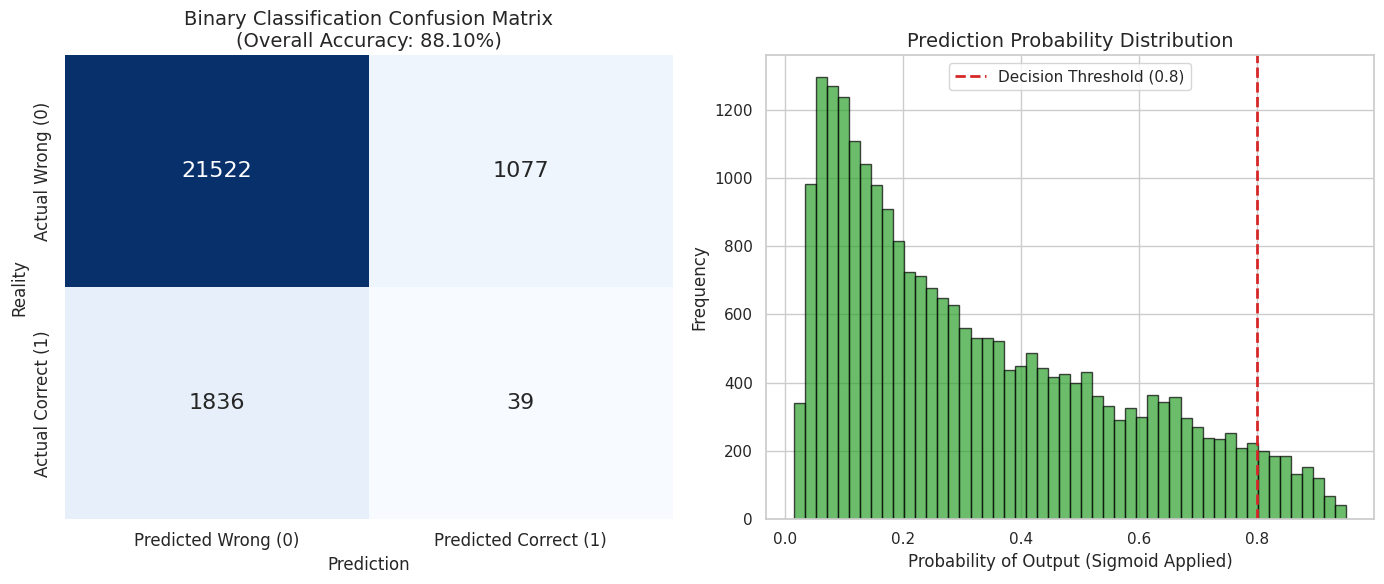

🎯 測試結果統計報告
總測試樣本數 : 24474 天
預測看漲(1)次數: 1116 次 (模型出手頻率)
預測看跌(0)次數: 23358 次
----------------------------------------
✅ 勝率 (Precision): 3.49 % (出手預測 1 中，真正獲利的比例)
📂 正在分析最新實驗結果：
./results/long_term_forecast_TSMC_Prediction_iTransformer_custom_ftMS_sl1000_ll48_pl1_dm256_nh8_el2_dl1_df1024_expand2_dc4_fc1_ebtimeF_dtTrue_new_Detector_0

✅ 檔案讀取成功！
➤ 原始陣列形狀 (Shape): (24474, 1, 1)
➤ 總數據量: 24474 個數值

📊 數據極值分析:
➤ 全局最小值 (Min): -4.214453
➤ 全局最大值 (Max): 2.988012

💡 診斷結果: 【全部數據中】確實包含負數或大於 1 的數值！
👉 結論：這是純淨的【未經轉換的 Logits】。
✅ 您可以 100% 安心使用包含內建 Sigmoid 的 StockFocalLossWithLogits (或 BCEWithLogitsLoss)！


In [ ]:
# 7. 評估模型
# ==========================================
model_performance(result_dir='./results/', threshold=0.8)

# ==========================================
# 診斷 Double Sigmoid
diagnose_pred_format(result_dir='./results/')

In [ ]:
!rm -rf ./results/*
print("舊的實驗結果已清空！")

舊的實驗結果已清空！


# **查看對齊**

In [ ]:
from verify_alignment import verify_alignment

# 自動找最新資料夾
verify_df = verify_alignment(
    csv_path='./dataset/stock/stock_features.csv'
)

📂 自動偵測到最新實驗資料夾：
./results/long_term_forecast_TSMC_Prediction_iTransformer_custom_ftMS_sl1000_ll48_pl1_dm256_nh8_el2_dl1_df1024_expand2_dc4_fc1_ebtimeF_dtTrue_new_Detector_0

🕰️ 時間序列對齊診斷報告
✅ 對齊準確率: 100.00%
🎉 完美對齊！CSV target 與 Model True NPY 完全吻合。


# **回測收益**

In [ ]:
from backtest import backtest

backtest(
    csv_path='./dataset/stock/stock_features.csv',
    price_csv_path='./dataset/stock/raw_ohlcv.csv',
    result_dir='./results/',
    initial_capital=1000.0,
    position_size=3,
    take_profit_pct=0.02,   # ← 與訓練 tp_pct=0.02 一致
    stop_loss_pct=0.01,     # ← 與訓練 sl_pct=0.01 一致
    max_hold_days=1,
    cooldown_hours=4,
    prob_threshold=0.60
)


# **儲存訓練權重**

In [ ]:
import os

checkpoint_dir = './checkpoints/'
# 找出最新的 checkpoint 資料夾
folders = [os.path.join(checkpoint_dir, f) for f in os.listdir(checkpoint_dir) if os.path.isdir(os.path.join(checkpoint_dir, f))]
latest_folder = max(folders, key=os.path.getmtime)
model_path = os.path.join(latest_folder, 'checkpoint.pth')

print(f"🔥 最新的模型權重檔案在這裡：\n{model_path}")

🔥 最新的模型權重檔案在這裡：
./checkpoints/long_term_forecast_TSMC_Prediction_iTransformer_custom_ftMS_sl700_ll48_pl1_dm128_nh8_el2_dl1_df2048_expand2_dc4_fc1_ebtimeF_dtTrue_new_Detector_0/checkpoint.pth


In [ ]:
#將權重儲存在google drive中
from google.colab import drive
import shutil
import os

# 1. 掛載 Google Drive (執行後會跳出授權視窗，請點擊允許)
drive.mount('/content/drive')

# 2. 在您的雲端硬碟建立一個專屬資料夾來放模型
my_drive_path = '/content/drive/MyDrive/Quant_Models/iTransformer_Binary/'
os.makedirs(my_drive_path, exist_ok=True)

# 3. 複製剛剛找到的最新 checkpoint.pth 到雲端硬碟
destination = os.path.join(my_drive_path, 'long_2vs3_wr5percent.pth')
shutil.copy(model_path, destination)

print(f"✅ 模型權重已成功備份至您的 Google Drive！")
print(f"路徑：{destination}")

Mounted at /content/drive
✅ 模型權重已成功備份至您的 Google Drive！
路徑：/content/drive/MyDrive/Quant_Models/iTransformer_Binary/long_2vs3_wr5percent.pth
